**need to do:**
- try burn in
  
**check:**
- losses
- analogues
    + grid cell wise variances
    + regional averages variances
- rank histograms

- variability
    + where does it result from, latent map oder decoder (want variability from latent map right? what variability does model want?)

In [1]:
import numpy as np
from engression.loss_func import energy_loss, energy_loss_two_sample
import torch
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
import torch, gc
import pickle
import matplotlib.pyplot as plt

device: cpu


In [2]:
import torch

def gb(x): return x / (1024**3)

def cuda_info():
    for i in range(torch.cuda.device_count()):
        dev = torch.device(f"cuda:{i}")
        free, total = torch.cuda.mem_get_info(dev)   # bytes: free, total (CUDA driver view)
        allocated = torch.cuda.memory_allocated(dev) # bytes: tensors (PyTorch allocator)
        reserved  = torch.cuda.memory_reserved(dev)  # bytes: cached by PyTorch
    
        print(f"GPU {i}:")
        print(f"  Allocated (tensors): {gb(allocated):6.2f} GB")
        print(f"  Reserved  (cache):   {gb(reserved):6.2f} GB")
        print(f"  Free / Total (driver): {gb(free):6.2f} / {gb(total):.2f} GB")
        print()
        return

# Optional one-line summary per device:
# print(torch.cuda.memory_summary(device=None, abbreviated=True))


# Compare Loss (S1 S2)

In [2]:
# load torch arrays
#y_te = torch.load("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/y_te.pt", map_location=torch.device(device))
#gen1_te = torch.load("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen1_te.pt", map_location=torch.device(device))
#gen2_te = torch.load("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen2_te.pt", map_location=torch.device(device))

# compute energy loss for test samples
#nrgy_loss = energy_loss_two_sample(y_te, gen1_te, gen2_te, beta=1)
#nrgy_loss

tensor([21.2727, 39.5069, 36.4684], grad_fn=<CatBackward0>)

In [2]:
# load DPA predicted temperatures
# load torch arrays
dpa_t_samples_raw = []

#dpa_t_samples = []
y_te = torch.load("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/y_te.pt", map_location=torch.device(device))
for i in range(1,98):
    print(i)
    t_sample = torch.load(f"/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen{i}_te.pt", map_location=torch.device(device))
    dpa_t_samples_raw.append(t_sample)
    #if i != 0:
        #nrgy_loss_pre = energy_loss_two_sample(y_te, dpa_t_samples_raw[i-1], t_sample, beta=1)
        #nrgy_losses.append(nrgy_loss_pre)
        #cuda_info()
        #del t_sample  # and any big tensors: model outputs, loss, etc.
        #gc.collect()              # free Python-side
        #torch.cuda.empty_cache()



1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97


In [ ]:
# compute energy loss between true temperature and generated dpa distribution

nrgy_loss = energy_loss(y_te, dpa_t_samples_raw[:10])
nrgy_loss

In [4]:
y_te.shape

torch.Size([64000, 648])

In [2]:
# calculate loss values
nrgy_losses = []
s1_losses = []
s2_losses = []
#dpa_t_samples = []
y_te = torch.load("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/y_te.pt", map_location=torch.device(device))
for i in range(81,98):
    print(i)
    t_sample_1 = torch.load(f"/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen{i}_te.pt", map_location=torch.device(device))
    t_sample_2 = torch.load(f"/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen{i+1}_te.pt", map_location=torch.device(device))

    nrgy_loss_pre = energy_loss_two_sample(y_te, t_sample_1, t_sample_2, beta=1)
    print(nrgy_loss_pre)
    nrgy_losses.append(nrgy_loss_pre)
    #s1_losses.append(nrgy_loss_pre[1])
    #s2_losses.append(nrgy_loss_pre[2])

    # had to save the loss values separately due to kernel/memory reasons
    #with open("nrgy_losses.pkl", "wb") as f:
        #pickle.dump(nrgy_losses, f)
    

81
tensor([21.2675, 39.5257, 36.5165], grad_fn=<CatBackward0>)
82
tensor([21.2729, 39.5292, 36.5127], grad_fn=<CatBackward0>)
83
tensor([21.2984, 39.5157, 36.4347], grad_fn=<CatBackward0>)
84
tensor([21.2983, 39.5470, 36.4973], grad_fn=<CatBackward0>)
85
tensor([21.2934, 39.5270, 36.4672], grad_fn=<CatBackward0>)
86
tensor([21.2784, 39.5047, 36.4528], grad_fn=<CatBackward0>)
87
tensor([21.2791, 39.5019, 36.4455], grad_fn=<CatBackward0>)
88
tensor([21.2791, 39.5178, 36.4774], grad_fn=<CatBackward0>)
89
tensor([21.2667, 39.5181, 36.5028], grad_fn=<CatBackward0>)
90
tensor([21.2518, 39.4960, 36.4885], grad_fn=<CatBackward0>)
91
tensor([21.2911, 39.5066, 36.4310], grad_fn=<CatBackward0>)
92
tensor([21.2959, 39.5019, 36.4120], grad_fn=<CatBackward0>)
93
tensor([21.2926, 39.5003, 36.4153], grad_fn=<CatBackward0>)
94
tensor([21.2717, 39.5006, 36.4579], grad_fn=<CatBackward0>)
95
tensor([21.2754, 39.4964, 36.4420], grad_fn=<CatBackward0>)
96
tensor([21.2724, 39.5098, 36.4749], grad_fn=<CatBack

FileNotFoundError: [Errno 2] No such file or directory: '/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen98_te.pt'

In [3]:
# combine the 3 loss lists

# Load the pickle files
with open('nrgy_losses_predictions_1-40.pkl', 'rb') as f1:
    list1 = pickle.load(f1)

with open('nrgy_losses_predictions_41-80.pkl', 'rb') as f2:
    list2 = pickle.load(f2)

with open('nrgy_losses_predictions_81-96.pkl', 'rb') as f3:
    list3 = pickle.load(f3)

# Append the lists
combined_list = list1 + list2 + list3

# (Optional) Save the combined list
#with open('combined_losses.pkl', 'wb') as f_out:
    #pickle.dump(combined_list, f_out)

# (Optional) Print to verify
print(combined_list)

[tensor([21.2727, 39.5069, 36.4684], requires_grad=True), tensor([21.2883, 39.5224, 36.4683], requires_grad=True), tensor([21.2957, 39.5161, 36.4406], requires_grad=True), tensor([21.2632, 39.5113, 36.4963], requires_grad=True), tensor([21.2626, 39.5216, 36.5180], requires_grad=True), tensor([21.2909, 39.5278, 36.4738], requires_grad=True), tensor([21.2812, 39.4996, 36.4369], requires_grad=True), tensor([21.2814, 39.5065, 36.4502], requires_grad=True), tensor([21.3131, 39.5318, 36.4373], requires_grad=True), tensor([21.2950, 39.5348, 36.4797], requires_grad=True), tensor([21.2949, 39.5406, 36.4914], requires_grad=True), tensor([21.3180, 39.5448, 36.4536], requires_grad=True), tensor([21.3031, 39.5328, 36.4594], requires_grad=True), tensor([21.3030, 39.5408, 36.4757], requires_grad=True), tensor([21.3146, 39.5390, 36.4488], requires_grad=True), tensor([21.2640, 39.4916, 36.4551], requires_grad=True), tensor([21.2779, 39.5098, 36.4636], requires_grad=True), tensor([21.2992, 39.5523, 36.5

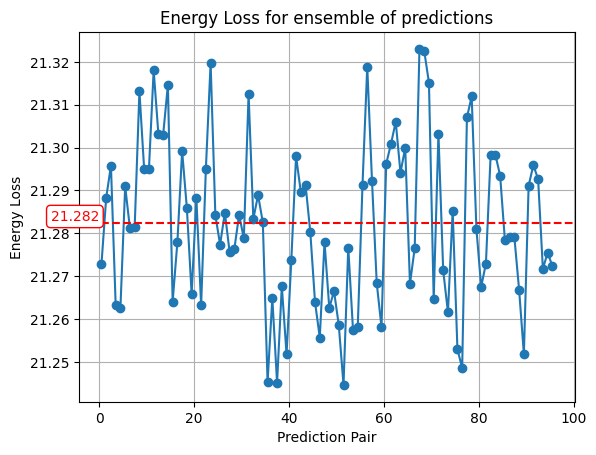

21.282273809115093 39.517905036608376 36.47126245498657


In [22]:
# Extract the first element from each tensor
first_elements = [tensor[0].item() for tensor in combined_list]
s1_elements = [tensor[1].item() for tensor in combined_list]
s2_elements = [tensor[2].item() for tensor in combined_list]

mean_value = sum(first_elements) / len(first_elements)
mean_s1 = sum(s1_elements) / len(s1_elements)
mean_s2 = sum(s2_elements) / len(s2_elements)

# Plotting
plt.plot(np.arange(0.5, 96.5, 1), first_elements, marker='o')
# plot mean value
plt.axhline(y=mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')
# Annotate the mean value on the plot
plt.text(
    x=0,     # x-position (right end of plot)
    y=mean_value ,  # y-position slightly above the line
    s=f'{mean_value:.3f}',
    color='red',
    ha='right',
    va='bottom',
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3')
)

plt.title("Energy Loss for ensemble of predictions")
plt.xlabel("Prediction Pair")
plt.ylabel("Energy Loss")
plt.grid(True)
plt.show()

print(mean_value, mean_s1, mean_s2)

# Analogues

In [ ]:
# compare distributions
# need many predictions -> produce! 

In [3]:
# create artificial PC score data (sample x feature)

# e.g. a 4×5 matrix with floats in [0,1)
sample = np.random.rand(1, 1001)
pcs = np.random.rand(2000, 1001)

# 1) compute the L2 distance from sample to each row in pcs
#    we can broadcast sample (1,1001) across pcs (2000,1001)
diff  = pcs - sample               # shape (2000,1001)
dists = np.linalg.norm(diff, axis=1)  # shape (2000,)

# 2) find the 20 smallest distances
top20_idx = np.argsort(dists)[:20]    # indices of the 20 nearest rows

# 3) slice out those rows
nearest_pcs = pcs[top20_idx]          # shape (20,1001)

print("Indices of nearest neighbors:", top20_idx)
print("Their distances:", dists[top20_idx])
print("Nearest rows shape:", nearest_pcs.shape)



# find n most similar samples

# get corresponding temperature values

Indices of nearest neighbors: [1449 1956 1988 1852 1827 1106  140  711 1128 1171  304  631 1028  843
 1278  734 1296 1719  450 1684]
Their distances: [12.21764779 12.23906226 12.24548657 12.29662825 12.31241267 12.31557022
 12.317937   12.32035282 12.33879005 12.34711729 12.36308875 12.36452106
 12.37113069 12.37735145 12.37897723 12.38033157 12.38681995 12.38939303
 12.39429999 12.39453351]
Nearest rows shape: (20, 1001)


In [4]:
print(sample[:,:10])
print(nearest_pcs[:,:10])

[[0.43356521 0.55968433 0.71729692 0.35666007 0.72333524 0.15201505
  0.88722263 0.41176347 0.40872331 0.5095015 ]]
[[0.55982028 0.77446909 0.60563307 0.10271103 0.69188155 0.17446635
  0.60485553 0.75298479 0.33878612 0.30714576]
 [0.94316356 0.2591141  0.04493539 0.51641395 0.28682578 0.44013074
  0.2999467  0.97031343 0.63672488 0.27157317]
 [0.26444362 0.7978479  0.32219451 0.30425148 0.19827394 0.23734438
  0.6385722  0.05174198 0.58073547 0.4818014 ]
 [0.73605813 0.59816675 0.63128486 0.11062662 0.54080609 0.90842526
  0.95252327 0.83438339 0.39675872 0.4174732 ]
 [0.53074837 0.71239044 0.1500737  0.54163917 0.09186262 0.16332809
  0.86767838 0.77314801 0.98340814 0.27031386]
 [0.44553706 0.02856296 0.34521626 0.7055495  0.346424   0.02588698
  0.14705836 0.5249867  0.36043626 0.76880556]
 [0.12255605 0.91639632 0.66641013 0.53763144 0.05095806 0.04274789
  0.45815758 0.19685109 0.7341351  0.080904  ]
 [0.55757468 0.56677603 0.60890796 0.74168855 0.40985328 0.64059743
  0.3749895

# Rank Histograms